In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import keras
from keras import models, layers, Input, optimizers
from keras.layers import TextVectorization

In [ ]:
# Task 1: Dataset Understanding
# Load the dataset
df = pd.read_csv('../ai_project_synthetic_datasets/part_3_nlp_sequence_modeling/customer_support_text_classification.csv')

num_records = len(df)
target_labels = df['sentiment_label'].unique().tolist()
sample_records = df[['customer_message', 'sentiment_label']].head(3).to_dict(orient='records')
avg_length = df['word_count'].mean()
class_counts = df['sentiment_label'].value_counts().to_dict()
class_percentages = df['sentiment_label'].value_counts(normalize=True).to_dict()

print(f"Number of records: {num_records}")
print(f"Target labels: {target_labels}")
print(f"Average text length: {avg_length:.2f} words")
print("\nClass Distribution Counts:")
for cls, count in class_counts.items():
    print(f" - {cls}: {count} ({class_percentages[cls]*100:.2f}%)")

print("\nSample Records:")
for sample in sample_records:
    print(f" -> Label: {sample['sentiment_label']} | Text: {sample['customer_message']}")

Number of records: 1500
Target labels: ['neutral', 'positive', 'negative']
Average text length: 12.72 words

Class Distribution Counts:
 - neutral: 524 (34.93%)
 - negative: 497 (33.13%)
 - positive: 479 (31.93%)

Sample Records:
 -> Label: neutral | Text: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
 -> Label: neutral | Text: I need information about the payment process.
 -> Label: positive | Text: The refund process was fast and convenient. I appreciate the quick response.


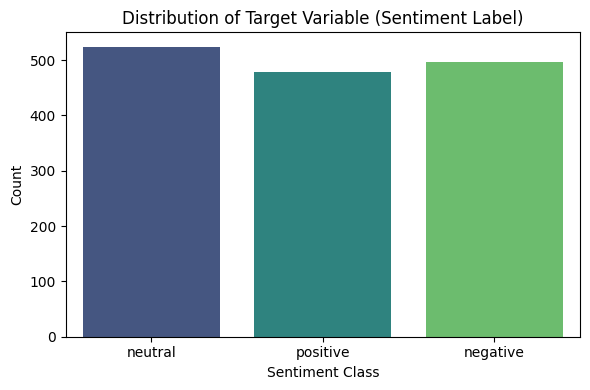

In [ ]:
# target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment_label', data=df, hue='sentiment_label', palette='viridis', legend=False)
plt.title('Distribution of Target Variable (Sentiment Label)')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# Task 2 and 3: Text Preprocessing and Text Vectorization
# to convert target labels to multi-class index representations
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment_label'].map(label_map)

X = df['customer_message']
y = df['label']

# Global NLP Modeling Hyperparameters
MAX_VOCAB_SIZE = 1000
MAX_SEQUENCE_LENGTH = 20
BATCH_SIZE = 32
EPOCHS = 15

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Keras 3 TextVectorization layer handles lowercasing, stripping special characters,
# tokenizing, and padding/truncating sequences simultaneously.
vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH,
    standardize='lower_and_strip_punctuation'
)

vectorizer.adapt(X_train.values)

# to transform text instances to padded numerical integer arrays
X_train_seq = vectorizer(X_train.values).numpy()
X_test_seq = vectorizer(X_test.values).numpy()

y_train = y_train.values
y_test = y_test.values

print(f"Processed Training Matrix Shape: {X_train_seq.shape}")
print(f"Processed Testing Matrix Shape:  {X_test_seq.shape}")
print(f"Vocabulary Size Extracted:       {len(vectorizer.get_vocabulary())} units")
print(f"\nOriginal text line:\n'{X_train.iloc[0]}'")
print(f"\nKeras 3 Vectorized integer sequence output:\n{X_train_seq[0]}")

Processed Training Matrix Shape: (1200, 20)
Processed Testing Matrix Shape:  (300, 20)
Vocabulary Size Extracted:       561 units

Original text line:
'Can you confirm whether my ticket has been assigned? Please respond as soon as possible.'

Keras 3 Vectorized integer sequence output:
[21 19 92 91  4  7 16 93 94 11 14  8 13  8 15  0  0  0  0  0]


In [ ]:
# Task 4: Baseline Model
baseline_model = models.Sequential(name="Baseline_Dense_Model")
baseline_model.add(Input(shape=(MAX_SEQUENCE_LENGTH,)))
baseline_model.add(layers.Dense(units=32, activation='relu'))
baseline_model.add(layers.Dropout(0.2))
baseline_model.add(layers.Dense(units=3, activation='softmax'))

baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_history = baseline_model.fit(
    X_train_seq, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

# Baseline performance evaluation
baseline_preds_prob = baseline_model.predict(X_test_seq, verbose=0)
baseline_preds = np.argmax(baseline_preds_prob, axis=1)

baseline_acc = accuracy_score(y_test, baseline_preds)
print(f"\nBaseline Model Testing Accuracy: {baseline_acc:.4f}")

Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3602 - loss: 35.6720 - val_accuracy: 0.4167 - val_loss: 18.7211
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4213 - loss: 23.1631 - val_accuracy: 0.4417 - val_loss: 11.7253
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4657 - loss: 17.9001 - val_accuracy: 0.5333 - val_loss: 7.9952
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5250 - loss: 11.6414 - val_accuracy: 0.5500 - val_loss: 6.0722
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5574 - loss: 9.0293 - val_accuracy: 0.6333 - val_loss: 4.5735
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5852 - loss: 7.3604 - val_accuracy: 0.6750 - val_loss: 3.4877
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6056 - loss: 6.4039 - val_accuracy: 0.7500 - val_loss: 2.9296
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6167 - loss: 5.7514 - val_accuracy: 0.7083 - va

In [ ]:
# Task 5: Sequence Model or Conceptual Architecture
# Input Sequence Layer
lstm_model = models.Sequential(name="Sequence_LSTM_Model")
lstm_model.add(Input(shape=(MAX_SEQUENCE_LENGTH,)))

# Embedding layer
lstm_model.add(layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=64, mask_zero=True))

# LSTM Layer
lstm_model.add(layers.LSTM(units=32, return_sequences=False))

# Dropout layer
lstm_model.add(layers.Dropout(0.3))

# Output layer
lstm_model.add(layers.Dense(units=3, activation='softmax'))

lstm_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X_train_seq, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

# LSTM performance evaluation
lstm_preds_prob = lstm_model.predict(X_test_seq, verbose=0)
lstm_preds = np.argmax(lstm_preds_prob, axis=1)

Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8333 - loss: 0.9588 - val_accuracy: 0.9583 - val_loss: 0.6006
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9889 - loss: 0.2551 - val_accuracy: 1.0000 - val_loss: 0.0506
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0310 - val_accuracy: 1.0000 - val_loss: 0.0129
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0143 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - v

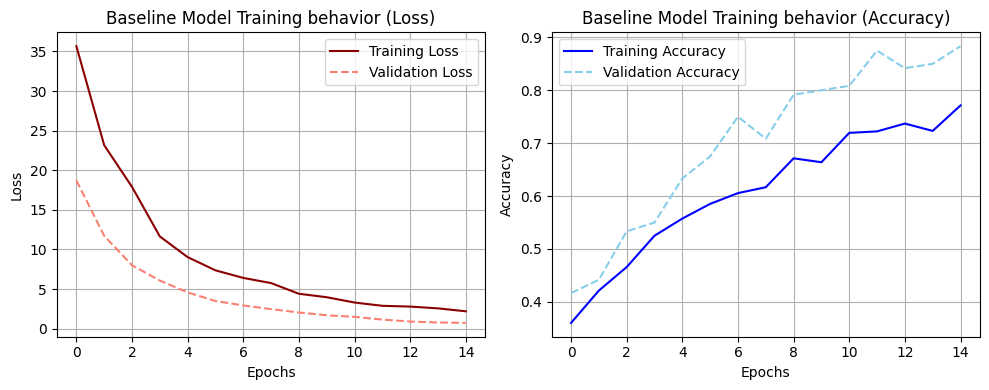


--- Baseline Model Classification Report ---
              precision    recall  f1-score   support

    negative       0.81      0.88      0.84        99
     neutral       0.91      0.91      0.91       105
    positive       0.93      0.85      0.89        96

    accuracy                           0.88       300
   macro avg       0.89      0.88      0.88       300
weighted avg       0.89      0.88      0.88       300


[INFO] 'results/model_evaluation.png' and 'results/sample_predictions.txt' saved successfully!


In [ ]:
# Creating a folder for outputs
os.makedirs('results', exist_ok=True)

plt.figure(figsize=(10, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['loss'], label='Training Loss', color='darkred')
plt.plot(baseline_history.history['val_loss'], label='Validation Loss', color='salmon', linestyle='--')
plt.title('Baseline Model Training behavior (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(baseline_history.history['val_accuracy'], label='Validation Accuracy', color='skyblue', linestyle='--')
plt.title('Baseline Model Training behavior (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('results/model_evaluation.png', dpi=300)
plt.show()

target_class_names = ['negative', 'neutral', 'positive']
print("\n--- Baseline Model Classification Report ---")
print(classification_report(y_test, baseline_preds, target_names=target_class_names))

# sample_predictions.txt for baseline model predictions
inverse_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

with open('results/sample_predictions.txt', 'w') as f:
    f.write("BASELINE MODEL SAMPLE PREDICTIONS\n")
    f.write("====================================================\n\n")
    
    # recording the first 10 text samples along with actual vs predicted labels
    for i in range(10):
        f.write(f"Sample #{i+1}\n")
        f.write(f"Customer Message: '{X_test.iloc[i]}'\n")
        f.write(f"Actual Label:      {inverse_map[y_test[i]]}\n")
        f.write(f"Predicted Label:   {inverse_map[baseline_preds[i]]}\n")
        f.write("----------------------------------------------------\n")

print("\n[INFO] 'results/model_evaluation.png' and 'results/sample_predictions.txt' saved successfully!")